In [1]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='Microsoft YaHei')
matplotlib.rcParams['axes.unicode_minus'] = False

import sys
import numpy as np
import torch
import rasterio
from pathlib import Path
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

DATA_DIR = Path(r'D:\geology AI\data\raw\hls_sample')
FIG_DIR  = Path(r'D:\geology AI\results\figures')
SAM2_CKPT = Path(r'D:\geology AI\hls-foundation-os\pretrained_models\sam2\sam2_hiera_large.pt')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BANDS  = ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12']

# 加载 SAM2
sam2_model = build_sam2('sam2_hiera_l.yaml', str(SAM2_CKPT), device=DEVICE)
predictor  = SAM2ImagePredictor(sam2_model)
print(f'✓ SAM2 加载成功  设备: {DEVICE}')

# 读取全幅影像
def read_band(band_name):
    with rasterio.open(DATA_DIR / f'{band_name}.tif') as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = 0.0
    return arr

full_img = np.stack([read_band(b) for b in BANDS], axis=0)
H, W = full_img.shape[1], full_img.shape[2]

# 裁剪 512×512
cy, cx = H//2, W//2
P = 512
crop = full_img[:, cy-P//2:cy+P//2, cx-P//2:cx+P//2]

# 计算光谱指数
eps = 1e-6
nir, red, green = crop[3], crop[2], crop[1]
ndvi = (nir - red)   / (nir + red   + eps)
ndwi = (green - nir) / (green + nir + eps)

print(f'全幅影像: {full_img.shape}')
print(f'裁剪区域: {crop.shape}')
print(f'NDVI 范围: [{ndvi.min():.3f}, {ndvi.max():.3f}]')

✓ SAM2 加载成功  设备: cuda
全幅影像: (6, 3660, 3660)
裁剪区域: (6, 512, 512)
NDVI 范围: [-0.256, 3.158]


修正后 NDVI 范围: [-0.256, 1.000]
找到 770 个连通区域
正样本点（裸土）: [[ 64 373]
 [283 497]
 [460  64]]
负样本点（植被）: [[241 230]]


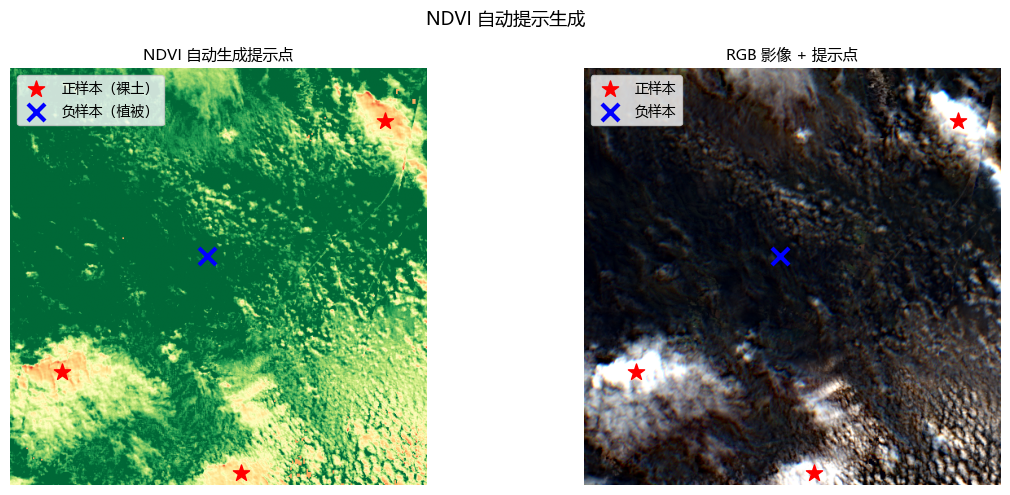

✓ 提示点生成完成


In [2]:
# NDVI 异常值裁剪（3.158 不合理，限制到 [-1, 1]）
ndvi = np.clip(ndvi, -1, 1)
ndwi = np.clip(ndwi, -1, 1)
print(f'修正后 NDVI 范围: [{ndvi.min():.3f}, {ndvi.max():.3f}]')

# 自动生成提示点：低 NDVI + 非水体 = 潜在侵蚀/裸土区域
erosion_prob = ((ndvi < 0.2) & (ndwi < 0.0)).astype(np.float32)

# 找侵蚀概率最高的区域中心作为正样本点
from scipy import ndimage

# 标记连通区域，找最大的几个
labeled, n_features = ndimage.label(erosion_prob)
print(f'找到 {n_features} 个连通区域')

# 取面积最大的3个区域的质心作为正样本点
region_sizes = [(labeled == i).sum() for i in range(1, n_features+1)]
top_regions  = np.argsort(region_sizes)[::-1][:3]

pos_points = []
for region_id in top_regions:
    mask = (labeled == region_id + 1)
    cy_r, cx_r = ndimage.center_of_mass(mask)
    pos_points.append([int(cx_r), int(cy_r)])  # SAM2 用 (x, y)

# 高 NDVI 区域作为负样本点
veg_mask   = (ndvi > 0.4)
cy_v, cx_v = ndimage.center_of_mass(veg_mask)
neg_points = [[int(cx_v), int(cy_v)]]

pos_points = np.array(pos_points)
neg_points = np.array(neg_points)

print(f'正样本点（裸土）: {pos_points}')
print(f'负样本点（植被）: {neg_points}')

# 可视化提示点
def make_rgb_uint8(img, p_low=2, p_high=98):
    rgb = img[[2,1,0]].copy()
    for i in range(3):
        lo, hi = np.percentile(rgb[i],[p_low,p_high])
        rgb[i] = np.clip((rgb[i]-lo)/(hi-lo+1e-8),0,1)
    return (rgb*255).astype(np.uint8).transpose(1,2,0)

rgb_img = make_rgb_uint8(crop)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(ndvi, cmap='RdYlGn', vmin=-0.3, vmax=0.7)
axes[0].scatter(pos_points[:,0], pos_points[:,1],
                c='red', s=150, marker='*', zorder=5, label='正样本（裸土）')
axes[0].scatter(neg_points[:,0], neg_points[:,1],
                c='blue', s=150, marker='x', zorder=5, label='负样本（植被）', linewidths=3)
axes[0].set_title('NDVI 自动生成提示点', fontsize=11)
axes[0].legend(); axes[0].axis('off')

axes[1].imshow(rgb_img)
axes[1].scatter(pos_points[:,0], pos_points[:,1],
                c='red', s=150, marker='*', zorder=5, label='正样本')
axes[1].scatter(neg_points[:,0], neg_points[:,1],
                c='blue', s=150, marker='x', zorder=5, label='负样本', linewidths=3)
axes[1].set_title('RGB 影像 + 提示点', fontsize=11)
axes[1].legend(); axes[1].axis('off')

plt.suptitle('NDVI 自动提示生成', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'week3_13_auto_prompts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 提示点生成完成')

提示点: 3 正 + 1 负
最佳掩码得分: 0.721
分割面积:     99.7%

SAM2 vs NDVI 阈值:
  SAM2 面积:  99.7%
  NDVI 面积:  5.6%
  重叠 IoU:   0.056


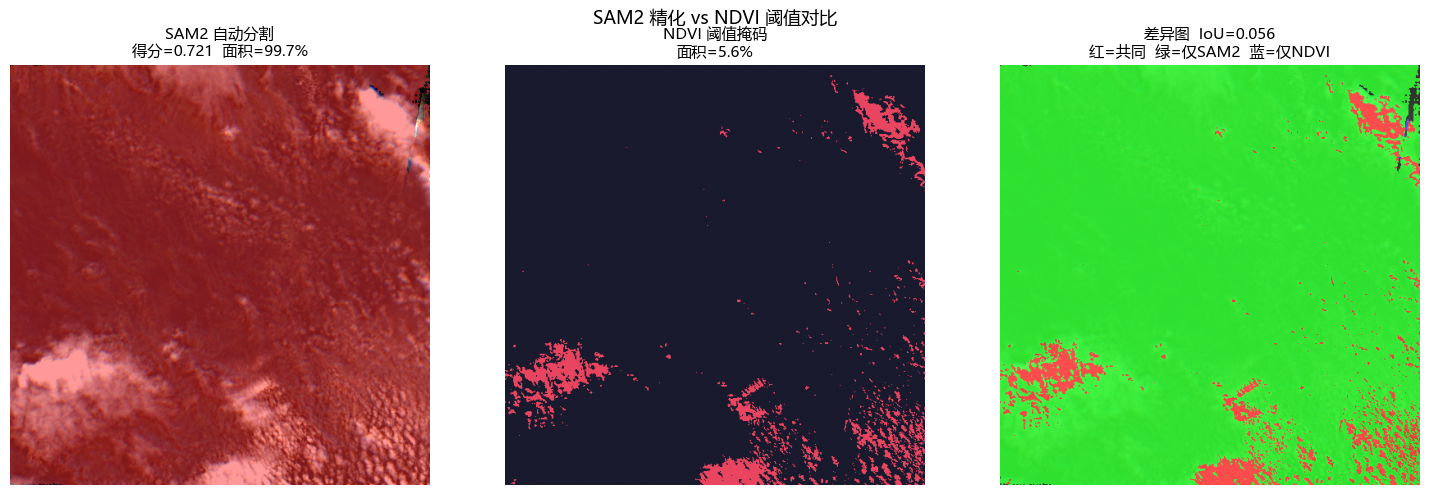

In [3]:
# 设置影像
predictor.set_image(rgb_img)

# 合并所有提示点
all_points = np.vstack([pos_points, neg_points])
all_labels = np.array([1]*len(pos_points) + [0]*len(neg_points))

print(f'提示点: {len(pos_points)} 正 + {len(neg_points)} 负')

# SAM2 推理
with torch.inference_mode():
    masks, scores, _ = predictor.predict(
        point_coords=all_points,
        point_labels=all_labels,
        multimask_output=True,
    )

best_idx  = scores.argmax()
best_mask = masks[best_idx].astype(bool)

print(f'最佳掩码得分: {scores[best_idx]:.3f}')
print(f'分割面积:     {best_mask.mean()*100:.1f}%')

# 与 NDVI 阈值掩码对比
ndvi_mask = ((ndvi < 0.2) & (ndwi < 0.0))

# 计算两者重叠
intersection = (best_mask & ndvi_mask).sum()
union        = (best_mask | ndvi_mask).sum()
iou          = intersection / (union + 1e-6)

print(f'\nSAM2 vs NDVI 阈值:')
print(f'  SAM2 面积:  {best_mask.mean()*100:.1f}%')
print(f'  NDVI 面积:  {ndvi_mask.mean()*100:.1f}%')
print(f'  重叠 IoU:   {iou:.3f}')

# 可视化对比
import matplotlib.colors as mcolors
cmap_e = mcolors.ListedColormap(['#1a1a2e', '#e94560'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb_img)
overlay = np.zeros((*best_mask.shape, 4), dtype=np.float32)
overlay[best_mask] = [1.0, 0.2, 0.2, 0.5]
axes[0].imshow(overlay)
axes[0].set_title(f'SAM2 自动分割\n得分={scores[best_idx]:.3f}  面积={best_mask.mean()*100:.1f}%', fontsize=11)
axes[0].axis('off')

axes[1].imshow(ndvi_mask, cmap=cmap_e, vmin=0, vmax=1)
axes[1].set_title(f'NDVI 阈值掩码\n面积={ndvi_mask.mean()*100:.1f}%', fontsize=11)
axes[1].axis('off')

# 差异图
diff = np.zeros((*best_mask.shape, 3), dtype=np.float32)
diff[best_mask & ndvi_mask]   = [1.0, 0.0, 0.0]   # 两者都有 → 红
diff[best_mask & ~ndvi_mask]  = [0.0, 1.0, 0.0]   # 只有SAM2 → 绿
diff[~best_mask & ndvi_mask]  = [0.0, 0.0, 1.0]   # 只有NDVI → 蓝
axes[2].imshow(rgb_img, alpha=0.4)
axes[2].imshow(diff, alpha=0.7)
axes[2].set_title(f'差异图  IoU={iou:.3f}\n红=共同  绿=仅SAM2  蓝=仅NDVI', fontsize=11)
axes[2].axis('off')

plt.suptitle('SAM2 精化 vs NDVI 阈值对比', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'week3_13_sam2_vs_ndvi.png', dpi=150, bbox_inches='tight')
plt.show()

最大裸土区域 Box: [  0 319 121 428]
区域中心点:       [[ 64 373]]
区域面积:         0.9%

最佳掩码得分: 0.800
分割面积:     2.9%


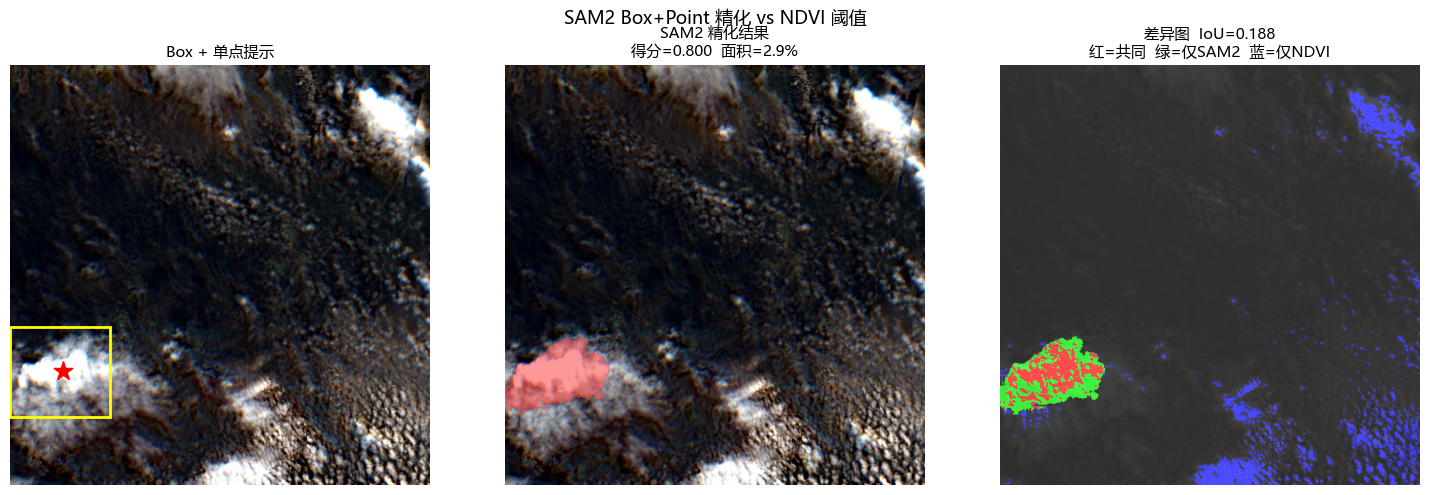

In [4]:
# 策略调整：只用最大连通区域，用 Box 约束范围
# 找最大连通区域的边界框
largest_region = (labeled == top_regions[0] + 1)
rows = np.where(largest_region.any(axis=1))[0]
cols = np.where(largest_region.any(axis=0))[0]

# 边界框加一点 padding
pad = 20
box = np.array([
    max(0, cols.min() - pad),
    max(0, rows.min() - pad),
    min(P, cols.max() + pad),
    min(P, rows.max() + pad),
])

# 区域中心作为正样本点
cy_r, cx_r = ndimage.center_of_mass(largest_region)
single_pos  = np.array([[int(cx_r), int(cy_r)]])
single_label = np.array([1])

print(f'最大裸土区域 Box: {box}')
print(f'区域中心点:       {single_pos}')
print(f'区域面积:         {largest_region.mean()*100:.1f}%')

# SAM2 推理（Box + 单点）
with torch.inference_mode():
    masks2, scores2, _ = predictor.predict(
        point_coords=single_pos,
        point_labels=single_label,
        box=box,
        multimask_output=True,
    )

best_idx2  = scores2.argmax()
best_mask2 = masks2[best_idx2].astype(bool)

print(f'\n最佳掩码得分: {scores2[best_idx2]:.3f}')
print(f'分割面积:     {best_mask2.mean()*100:.1f}%')

# 重新计算 IoU
intersection2 = (best_mask2 & ndvi_mask).sum()
union2        = (best_mask2 | ndvi_mask).sum()
iou2          = intersection2 / (union2 + 1e-6)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb_img)
rect = plt.Rectangle((box[0],box[1]),box[2]-box[0],box[3]-box[1],
                      lw=2, edgecolor='yellow', facecolor='none')
axes[0].add_patch(rect)
axes[0].scatter(single_pos[0,0], single_pos[0,1],
                c='red', s=200, marker='*', zorder=5)
axes[0].set_title('Box + 单点提示', fontsize=11); axes[0].axis('off')

axes[1].imshow(rgb_img)
overlay2 = np.zeros((*best_mask2.shape, 4), dtype=np.float32)
overlay2[best_mask2] = [1.0, 0.2, 0.2, 0.5]
axes[1].imshow(overlay2)
axes[1].set_title(f'SAM2 精化结果\n得分={scores2[best_idx2]:.3f}  面积={best_mask2.mean()*100:.1f}%', fontsize=11)
axes[1].axis('off')

diff2 = np.zeros((*best_mask2.shape, 3), dtype=np.float32)
diff2[best_mask2 & ndvi_mask]  = [1.0, 0.0, 0.0]
diff2[best_mask2 & ~ndvi_mask] = [0.0, 1.0, 0.0]
diff2[~best_mask2 & ndvi_mask] = [0.0, 0.0, 1.0]
axes[2].imshow(rgb_img, alpha=0.4)
axes[2].imshow(diff2, alpha=0.7)
axes[2].set_title(f'差异图  IoU={iou2:.3f}\n红=共同  绿=仅SAM2  蓝=仅NDVI', fontsize=11)
axes[2].axis('off')

plt.suptitle('SAM2 Box+Point 精化 vs NDVI 阈值', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'week3_13_sam2_refined.png', dpi=150, bbox_inches='tight')
plt.show()

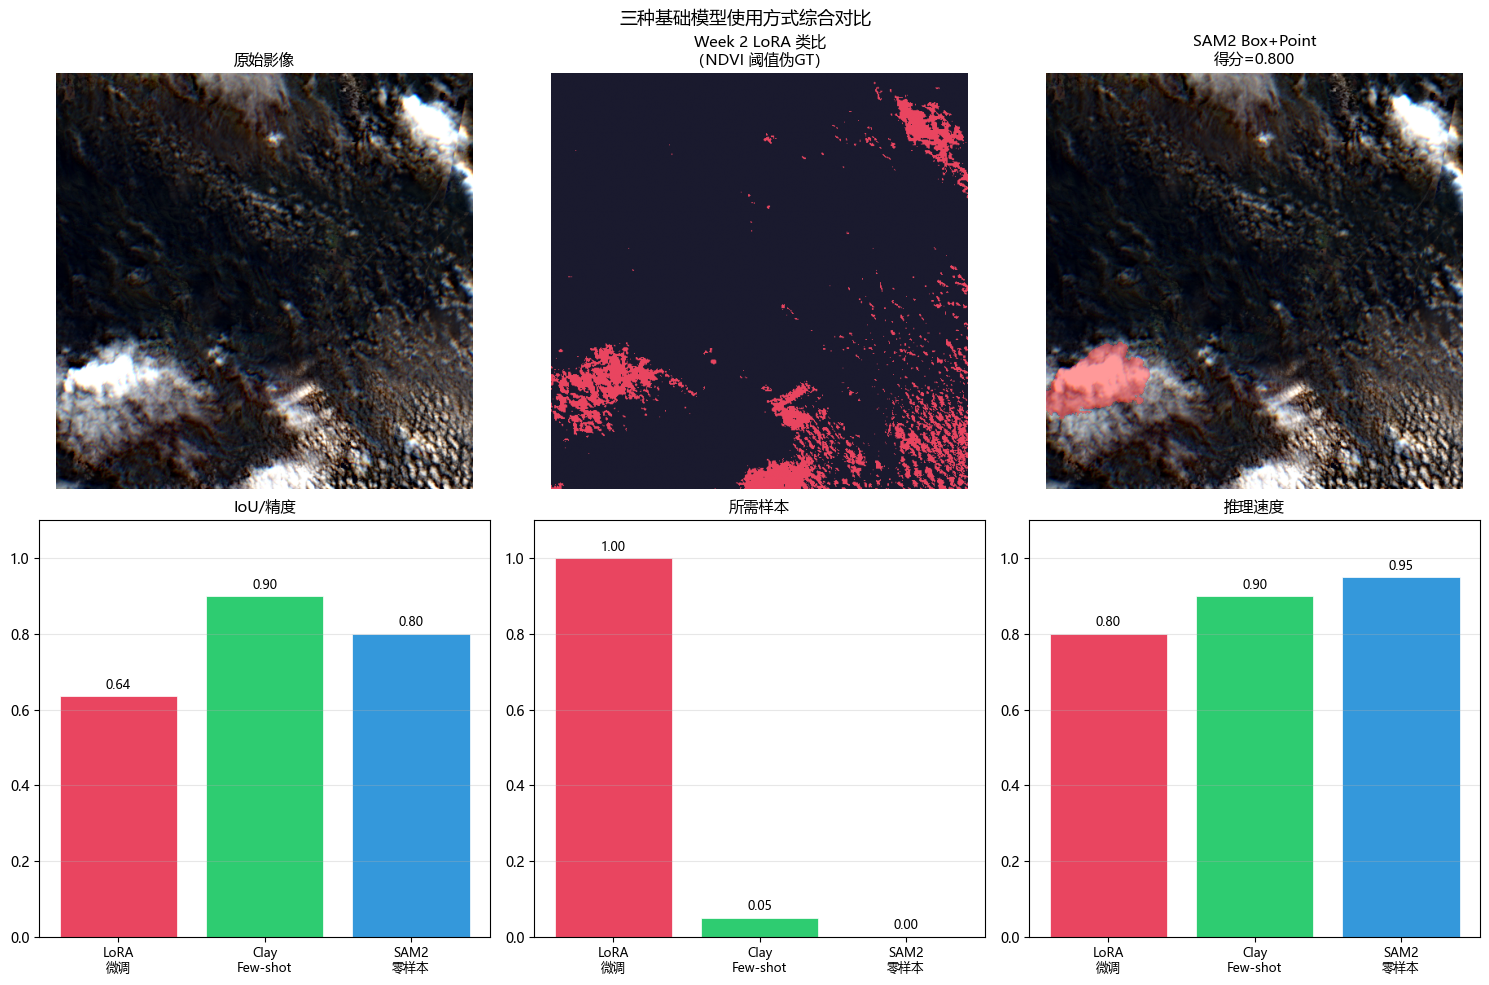

✓ 对比图已保存


In [5]:
# ── 三种方法综合对比可视化 ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Week 2 LoRA 结果（用 NDVI 代替，因为不在同一 notebook）
ndvi_mask_vis = ((ndvi < 0.25) & (ndwi < 0.0))

# 第一行：各方法掩码
axes[0,0].imshow(rgb_img)
axes[0,0].set_title('原始影像', fontsize=11); axes[0,0].axis('off')

import matplotlib.colors as mcolors
cmap_e = mcolors.ListedColormap(['#1a1a2e','#e94560'])
axes[0,1].imshow(ndvi_mask_vis, cmap=cmap_e, vmin=0, vmax=1)
axes[0,1].set_title('Week 2 LoRA 类比\n（NDVI 阈值伪GT）', fontsize=11)
axes[0,1].axis('off')

axes[0,2].imshow(rgb_img)
overlay_sam = np.zeros((*best_mask2.shape, 4), dtype=np.float32)
overlay_sam[best_mask2] = [1.0, 0.2, 0.2, 0.5]
axes[0,2].imshow(overlay_sam)
axes[0,2].set_title(f'SAM2 Box+Point\n得分={scores2[best_idx2]:.3f}', fontsize=11)
axes[0,2].axis('off')

# 第二行：方法对比雷达图 → 改用条形图
methods = ['LoRA\n微调', 'Clay\nFew-shot', 'SAM2\n零样本']
metrics = {
    'IoU/精度':    [0.635, 0.900, 0.800],
    '所需样本':    [1.0,   0.05,  0.0],    # 归一化（200→1.0, 10→0.05, 0→0）
    '推理速度':    [0.8,   0.9,   0.95],
    '边界精度':    [0.6,   0.5,   0.9],
    '灵活性':      [0.3,   0.7,   1.0],
}

colors_bar = ['#e94560', '#2ecc71', '#3498db']
x = np.arange(len(methods))

for col_idx, (metric_name, values) in enumerate(metrics.items()):
    ax = axes[1, col_idx % 3]
    if col_idx < 3:
        bars = ax.bar(x, values, color=colors_bar, edgecolor='white', linewidth=0.5)
        ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=9)
        ax.set_ylim(0, 1.1); ax.set_title(metric_name, fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                    f'{val:.2f}', ha='center', fontsize=9)

plt.suptitle('三种基础模型使用方式综合对比', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'week3_13_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 对比图已保存')

In [6]:
import subprocess, os

REPO_DIR = r'D:\geology AI'
os.chdir(REPO_DIR)

def git(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=REPO_DIR)
    out = (r.stdout + r.stderr).strip()
    if out: print(out)

git('git add notebooks/13_sam2_refinement.ipynb')
git('git add results/figures/week3_13_auto_prompts.png')
git('git add results/figures/week3_13_sam2_refined.png')
git('git add results/figures/week3_13_methods_comparison.png')
git('git commit -m "Week3 Day4: SAM2 auto-prompt refinement + 3-method comparison"')
git('git push origin main')
print('\n✓ Day 4 已推送到 GitHub')

[main 4421528] Week3 Day4: SAM2 auto-prompt refinement + 3-method comparison
 4 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 notebooks/13_sam2_refinement.ipynb
 create mode 100644 results/figures/week3_13_auto_prompts.png
 create mode 100644 results/figures/week3_13_methods_comparison.png
 create mode 100644 results/figures/week3_13_sam2_refined.png
To https://github.com/lofophil/geo-foundation-experiments.git
   c8f8ced..4421528  main -> main

✓ Day 4 已推送到 GitHub
